In [1]:
!pip install -U "protobuf<5" --force-reinstall --quiet
!pip install -U tensorflow --quiet  # optional, ensures clean rebuild
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide CUDA backend warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 7.7 MB/s eta 0:00:00ta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you 

In [16]:
# LIBRARIES
import os
import random
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from skimage import color
from pathlib import Path
import kagglehub
from tensorflow.keras.layers import Input
import imageio
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error

In [3]:
# DATASET
dataset_path = Path(kagglehub.dataset_download("akash2sharma/tiny-imagenet"))
tiny_path = dataset_path / "tiny-imagenet-200"
print("Dataset downloaded to:", tiny_path)

Dataset downloaded to: /kaggle/input/tiny-imagenet/tiny-imagenet-200


In [4]:
# GLOBAL VARS
IMG_SIZE = 64
N_BINS = 64

In [5]:
# DISCRETIZING AND PREPROCESSING FUNCTIONS
# Discretize ab values into discrete bins
def quantize_ab(ab):
    a = np.clip(((ab[...,0] + 1) / 2) * (N_BINS - 1), 0, N_BINS - 1).astype(int)
    b = np.clip(((ab[...,1] + 1) / 2) * (N_BINS - 1), 0, N_BINS - 1).astype(int)
    label = a * N_BINS + b
    return label

# Convert discrete bins to continuous ab values
def dequantize_ab(label):
    a = (label // N_BINS) / (N_BINS - 1) * 2 - 1
    b = (label % N_BINS) / (N_BINS - 1) * 2 - 1
    return np.stack([a, b], axis=-1)

# RGB -> Lab -> L + ab bin
def load_and_preprocess_image(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = color.rgb2lab(img).astype("float32")
    L = lab[:, :, 0:1] / 100.0
    ab = lab[:, :, 1:] / 128.0
    label = quantize_ab(ab)
    return L, label

In [6]:
# PER-CLASS SAMPLE + PER-CLASS 80/20 SPLIT
def sample_subset_split(source_dir, num_classes, samples_per_class, seed=42):
    random.seed(seed)
    train_dir = source_dir / "train"
    all_classes = sorted([c for c in train_dir.iterdir() if c.is_dir()])
    chosen_classes = random.sample(all_classes, num_classes)
    train_paths = []
    val_paths = []
    
    for cls in chosen_classes:
        img_dir = cls / "images"
        imgs = list(img_dir.glob("*.JPEG"))
        imgs = random.sample(imgs, min(samples_per_class, len(imgs)))
        split = int(0.8 * len(imgs))
        cls_train = imgs[:split]
        cls_val = imgs[split:]
        train_paths.extend(cls_train)
        val_paths.extend(cls_val)
    return train_paths, val_paths

train_paths, val_paths = sample_subset_split(tiny_path, num_classes=100, samples_per_class=300)
print(f"Train images: {len(train_paths)}, Val images: {len(val_paths)}")

def create_dataset(paths):
    Ls, labels = [], []
    for p in paths:
        L, label = load_and_preprocess_image(p)
        Ls.append(L)
        labels.append(label)
    return np.array(Ls), np.array(labels)

X_train, Y_train = create_dataset(train_paths)
X_val, Y_val = create_dataset(val_paths)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train images: 24000, Val images: 6000
Train: (24000, 64, 64, 1), Val: (6000, 64, 64, 1)


In [7]:
# U-NET
def unet_classifier(output_classes=N_BINS**2):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(bn)

    # Decoder
    u1 = layers.UpSampling2D((2, 2))(bn)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D((2, 2))(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)

    # Softmax classification for each pixel
    outputs = layers.Conv2D(output_classes, 1, activation='softmax')(c6)
    return models.Model(inputs, outputs)

In [8]:
# TRAIN
model = unet_classifier()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=70,
    batch_size=32,
    verbose=1
)

I0000 00:00:1765019953.049214      47 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765019953.049879      47 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/70


I0000 00:00:1765019978.649720     126 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/750 ━━━━━━━━━━━━━━━━━━━━ 236s 284ms/step - loss: 4.7886 - val_loss: 4.6095
Epoch 2/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 215s 286ms/step - loss: 4.6017 - val_loss: 4.5676
Epoch 3/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 215s 286ms/step - loss: 4.5545 - val_loss: 4.5270
Epoch 4/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 213s 284ms/step - loss: 4.5268 - val_loss: 4.5041
Epoch 5/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 212s 283ms/step - loss: 4.5023 - val_loss: 4.4775
Epoch 6/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 212s 283ms/step - loss: 4.4732 - val_loss: 4.4571
Epoch 7/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 212s 283ms/step - loss: 4.4541 - val_loss: 4.4521
Epoch 8/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 212s 282ms/step - loss: 4.4358 - val_loss: 4.4226
Epoch 9/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 281ms/step - loss: 4.4149 - val_loss: 4.4253
Epoch 10/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 210s 281ms/step - loss: 4.3936 - val_loss: 4.4037
Epoch 11/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 281ms/step - loss: 4.3699 - val_loss: 4.3981
Epoch 12/70
750/750

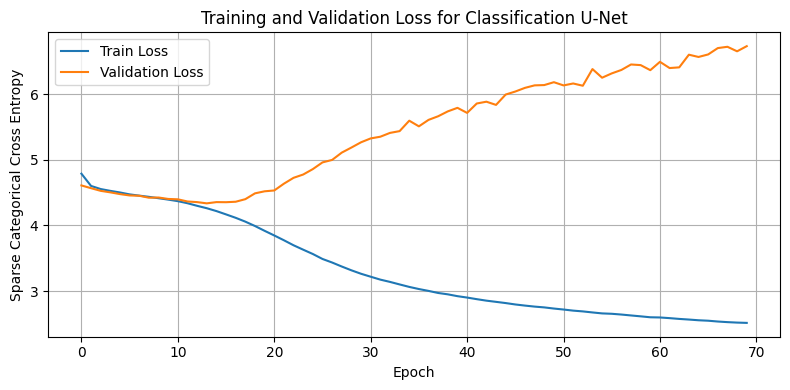

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Cross Entropy')
plt.title('Training and Validation Loss for Classification U-Net')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 4. Inference (convert class predictions back to colors)
# ============================================================

preds = model.predict(X_val[:5])
pred_labels = np.argmax(preds, axis=-1)  # (N,64,64)
pred_ab = np.array([dequantize_ab(lbl) for lbl in pred_labels])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


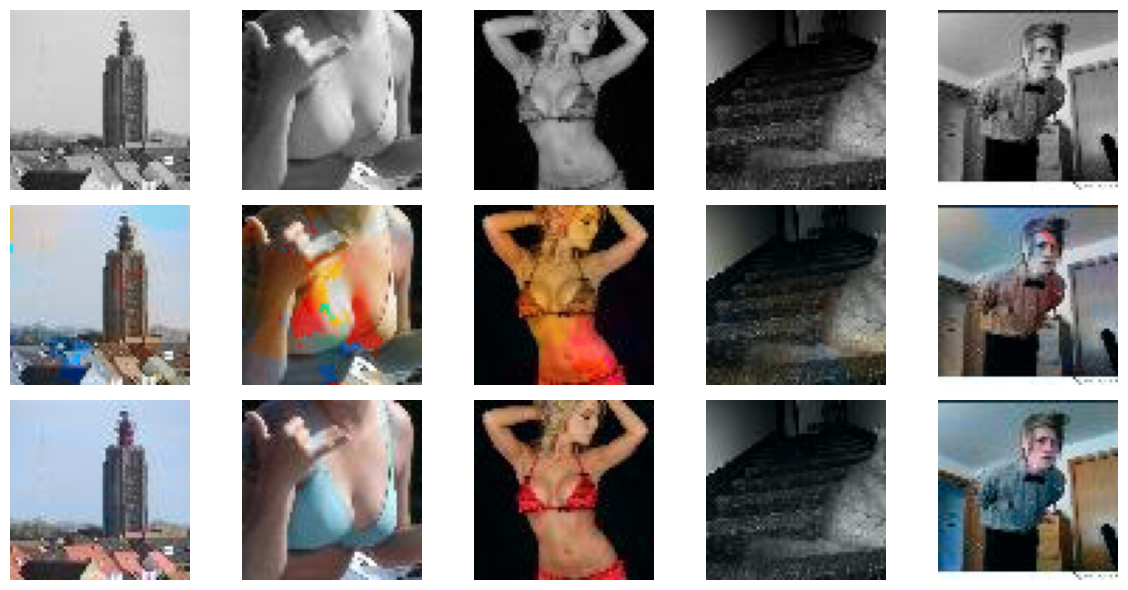

In [11]:
# # PREDICT ON TEST SET
# random.seed(777)
# np.random.seed(777)

# # Lab to RGB
# def lab_to_rgb(L, ab):
#     L = L * 100
#     ab = ab * 128
#     lab = np.concatenate((L, ab), axis=-1)
#     rgb = np.clip(color.lab2rgb(lab), 0, 1)
#     return rgb

# num_samples = 5
# idxs = random.sample(range(len(X_val)), num_samples)

# preds = model.predict(X_val[idxs])

# # Convert predictions -> class labels -> continuous ab
# pred_labels = np.argmax(preds, axis=-1)        
# pred_ab = np.array([dequantize_ab(lbl) for lbl in pred_labels])  

# plt.figure(figsize=(12, 6))
# for i, idx in enumerate(idxs):
#     L = X_val[idx]
#     ab_pred = pred_ab[i]
#     ab_true = dequantize_ab(Y_val[idx])
#     colorized_pred = lab_to_rgb(L, ab_pred)
#     colorized_true = lab_to_rgb(L, ab_true)
#     gray = np.repeat(L, 3, axis=-1)

#     plt.subplot(3, num_samples, i + 1)
#     plt.imshow(gray)
#     plt.axis('off')
#     if i == 0:
#         plt.ylabel("Input", fontsize=12)

#     plt.subplot(3, num_samples, i + 1 + num_samples)
#     plt.imshow(colorized_pred)
#     plt.axis('off')
#     if i == 0:
#         plt.ylabel("Predicted", fontsize=12)

#     plt.subplot(3, num_samples, i + 1 + 2*num_samples)
#     plt.imshow(colorized_true)
#     plt.axis('off')
#     if i == 0:
#         plt.ylabel("Ground Truth", fontsize=12)

# plt.tight_layout()
# plt.show()

In [ ]:
# 1 "/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1018.JPEG"
# 2 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_0.JPEG'
# 3 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1078.JPEG'
# 4 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1103.JPEG'
# 5 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1129.JPEG'
# 6 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1186.JPEG'
# 7 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1202.JPEG'
# 8 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_132.JPEG'
# 9 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1314.JPEG'
# 10 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_2005.JPEG'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Saved images to: single_output
MSE:  0.002457
SSIM: 0.931569


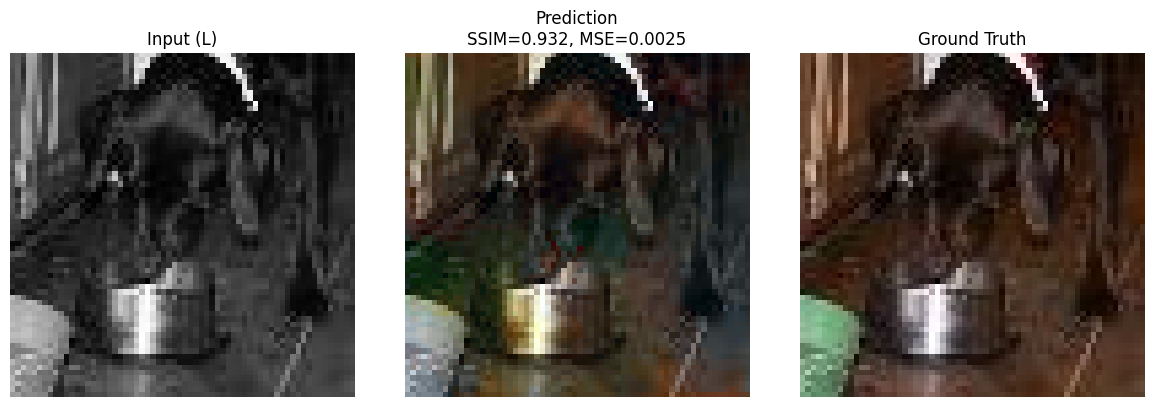

In [29]:
# PREDICT ON ONE IMAGE OF CHOICE
img_path = "/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_2005.JPEG"

# Load image
rgb = cv2.imread(img_path)[:, :, ::-1]
rgb = cv2.resize(rgb, (64, 64))
rgb_norm = rgb / 255.0

# Preprocess image
lab = color.rgb2lab(rgb_norm)
L = lab[:, :, 0:1] / 100.0
ab_true = lab[:, :, 1:] / 128.0
L_batch = np.expand_dims(L, axis=0)

# ---- EDIT: prediction → argmax classes → dequantize ----
pred_logits = model.predict(L_batch)[0]               # (64, 64, 4096)
pred_classes = np.argmax(pred_logits, axis=-1)        # (64, 64)
ab_pred = dequantize_ab(pred_classes)                 # back to continuous ab

# Convert to RGB
def lab_to_rgb(L, ab):
    L2 = L * 100
    ab2 = ab * 128
    lab = np.concatenate((L2, ab2), axis=-1)
    rgb = color.lab2rgb(lab)
    return np.clip(rgb, 0, 1)

colorized_pred = lab_to_rgb(L, ab_pred)
colorized_true = lab_to_rgb(L, ab_true)
gray = np.repeat(L, 3, axis=-1)

# SAVE IMAGES 
out_dir = "single_output"
os.makedirs(out_dir, exist_ok=True)
imageio.imwrite(f"{out_dir}/grayscale10.png", (gray * 255).astype(np.uint8))
imageio.imwrite(f"{out_dir}/predicted10.png", (colorized_pred * 255).astype(np.uint8))
imageio.imwrite(f"{out_dir}/ground_truth10.png", (colorized_true * 255).astype(np.uint8))
print("Saved images to:", out_dir)

# COMPUTE SSIM & MSE
mse_val = mean_squared_error(colorized_true.flatten(), colorized_pred.flatten())
ssim_val = ssim(colorized_true, colorized_pred, channel_axis=2, data_range=1.0)
print(f"MSE:  {mse_val:.6f}")
print(f"SSIM: {ssim_val:.6f}")

# PLOT
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray)
plt.axis("off")
plt.title("Input (L)")

plt.subplot(1, 3, 2)
plt.imshow(colorized_pred)
plt.axis("off")
plt.title(f"Prediction\nSSIM={ssim_val:.3f}, MSE={mse_val:.4f}")

plt.subplot(1, 3, 3)
plt.imshow(colorized_true)
plt.axis("off")
plt.title("Ground Truth")

plt.tight_layout()
plt.show()